In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc
import lightgbm as lgb
import warnings
import gc
import os
from scipy import stats
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
!pip install -q kaggle
!mkdir -p ~/.kaggle

In [3]:
mkdir -p ~/.kaggle && echo KGAT_e2314a1523959650306276bcafce11f1 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [4]:
!kaggle competitions download -c ieee-fraud-detection
!unzip ieee-fraud-detection.zip
train_trans = pd.read_csv("train_transaction.csv")
train_iden  = pd.read_csv("train_identity.csv")
test_trans  = pd.read_csv("test_transaction.csv")
test_iden   = pd.read_csv("test_identity.csv")

100% 118M/118M [00:00<00:00, 128MB/s]

Archive:  ieee-fraud-detection.zip
  inflating: sample_submission.csv   
  inflating: test_identity.csv       
  inflating: test_transaction.csv    
  inflating: train_identity.csv      
  inflating: train_transaction.csv   


In [5]:
# Merge transaction and identity data on TransactionID
train = train_trans.merge(train_iden, on='TransactionID', how='left')
test = test_trans.merge(test_iden, on='TransactionID', how='left')

print(f"Train Shape after merge: {train.shape}")
print(f"Test Shape after merge: {test.shape}")

# Free memory
del train_trans, test_trans, train_iden, test_iden
gc.collect()

Train Shape after merge: (590540, 434)
Test Shape after merge: (506691, 433)


0

## 4. Exploratory Data Analysis

Target Distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud Rate: 3.50%


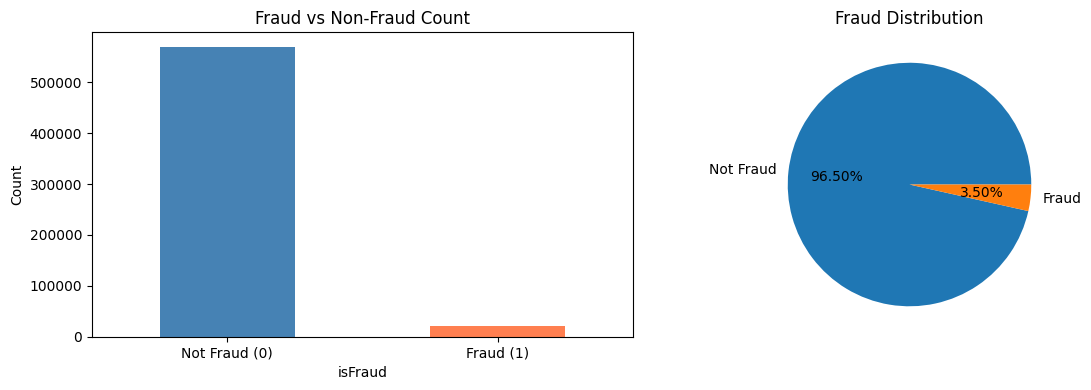

In [6]:
# Check target distribution
print("Target Distribution:")
print(train['isFraud'].value_counts())
print(f"\nFraud Rate: {train['isFraud'].mean() * 100:.2f}%")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['isFraud'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Fraud vs Non-Fraud Count')
axes[0].set_xlabel('isFraud')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Not Fraud (0)', 'Fraud (1)'], rotation=0)

train['isFraud'].value_counts().plot(kind='pie', autopct='%1.2f%%', labels=['Not Fraud', 'Fraud'])
axes[1].set_title('Fraud Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [7]:
def reduce_mem_usage(df, verbose=True):
    """Reduce memory usage by converting data types"""
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Memory usage: {start_mem:.2f} MB -> {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

In [8]:
##skewness check
train['TransactionAmt'].skew()

np.float64(14.374489573829827)

In [9]:
train['TransactionAmt'].describe()

,TransactionAmt
count,590540.000000
mean,135.027176
std,239.162522
min,0.251000
25%,43.321000
50%,68.769000
75%,125.000000
max,31937.391000


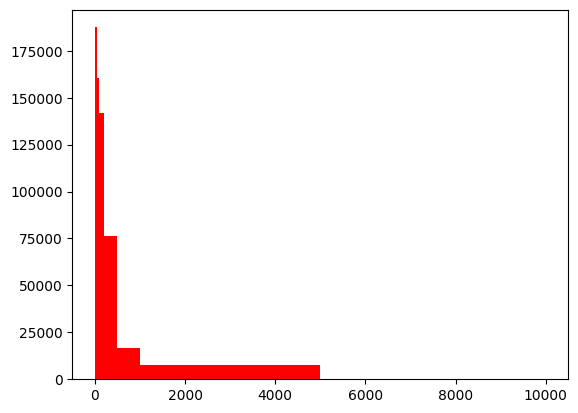

In [10]:
#Bining
plt.hist(train['TransactionAmt'], bins=[0, 50, 100, 200, 500, 1000, 5000, 10000],color='red')
plt.show()

In [11]:
(train['TransactionAmt'] * 100 % 100).astype(int).value_counts()

,count
TransactionAmt,
0,305621
95,159018
50,21933
94,11275
97,8035
...,...
14,634
16,633
12,628


In [12]:
def create_transaction_amount_features(df):
    # Log transformation
    df['TransactionAmt_Log'] = np.log1p(df['TransactionAmt'])

    # Decimal part (cents) - often fraudsters use round numbers
    df['TransactionAmt_decimal'] = ((df['TransactionAmt'] - df['TransactionAmt'].astype(int)) * 1000).astype(int)

    # Is round amount (no cents)
    df['TransactionAmt_is_round'] = (df['TransactionAmt'] == df['TransactionAmt'].astype(int)).astype(int)

    # Amount bins
    df['TransactionAmt_bin'] = pd.cut(df['TransactionAmt'],
                                     bins=[0, 50, 100, 200, 500, 1000, 5000, 10000, np.inf],
                                     labels=[0, 1, 2, 3, 4, 5, 6, 7]).astype(float)

    # Cents value
    df['TransactionAmt_cents'] = (df['TransactionAmt'] * 100 % 100).astype(int)

    # Common fraud amounts (ends in .00, .99, .95)
    df['TransactionAmt_ends_00'] = (df['TransactionAmt_cents'] == 0).astype(int)
    df['TransactionAmt_ends_99'] = (df['TransactionAmt_cents'] == 99).astype(int)
    df['TransactionAmt_ends_95'] = (df['TransactionAmt_cents'] == 95).astype(int)
    df['TransactionAmt_ends_50'] = (df['TransactionAmt_cents'] == 50).astype(int)
    return df

# Apply
train = create_transaction_amount_features(train)
test = create_transaction_amount_features(test)

In [13]:
def create_time_features(df):
    """Create time-based features from TransactionDT"""
    print("Creating time features...")

    # TransactionDT is seconds from a reference point
    # Convert to interpretable time units

    # Hour of day (0-23)
    df['Transaction_hour'] = np.floor(df['TransactionDT'] / 3600) % 24

    # Day of week (0-6)
    df['Transaction_dow'] = np.floor(df['TransactionDT'] / (3600 * 24)) % 7

    # Day of month approximation
    df['Transaction_dom'] = np.floor(df['TransactionDT'] / (3600 * 24)) % 30

    # Week number
    df['Transaction_week'] = np.floor(df['TransactionDT'] / (3600 * 24 * 7))

    # Is weekend
    df['Transaction_is_weekend'] = (df['Transaction_dow'] >= 5).astype(int)

    # Time of day categories
    df['Transaction_time_of_day'] = pd.cut(df['Transaction_hour'],
                                            bins=[-1, 6, 12, 18, 24],
                                            labels=[0, 1, 2, 3]).astype(float)  # night, morning, afternoon, evening

    # Is night (00:00 - 06:00) - higher fraud risk
    df['Transaction_is_night'] = ((df['Transaction_hour'] >= 0) & (df['Transaction_hour'] < 6)).astype(int)

    # Is business hours (09:00 - 17:00)
    df['Transaction_is_business_hours'] = ((df['Transaction_hour'] >= 9) & (df['Transaction_hour'] < 17)).astype(int)

    return df

# Apply
train = create_time_features(train)
test = create_time_features(test)

Creating time features...
Creating time features...


In [14]:
def create_card_features(df):
    """Create features based on card information"""
    print("Creating card features...")

    # Card combination features
    card_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']

    for col in card_cols:
        if col in df.columns:
            # Fill NaN for string operations
            df[col] = df[col].fillna(-999)

    # Card1 + Card2 combination
    if 'card1' in df.columns and 'card2' in df.columns:
        df['card1_card2'] = df['card1'].astype(str) + '_' + df['card2'].astype(str)

    # Card type combinations
    if 'card4' in df.columns and 'card6' in df.columns:
        df['card4_card6'] = df['card4'].astype(str) + '_' + df['card6'].astype(str)

    # Card + Address combinations
    if 'card1' in df.columns and 'addr1' in df.columns:
        df['card1_addr1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)

    if 'card1' in df.columns and 'addr2' in df.columns:
        df['card1_addr2'] = df['card1'].astype(str) + '_' + df['addr2'].astype(str)

    if 'card2' in df.columns and 'addr1' in df.columns:
        df['card2_addr1'] = df['card2'].astype(str) + '_' + df['addr1'].astype(str)

    # Card + Product combinations
    if 'card1' in df.columns and 'ProductCD' in df.columns:
        df['card1_ProductCD'] = df['card1'].astype(str) + '_' + df['ProductCD'].astype(str)

    if 'card2' in df.columns and 'ProductCD' in df.columns:
        df['card2_ProductCD'] = df['card2'].astype(str) + '_' + df['ProductCD'].astype(str)

    # Card + Time combinations
    if 'card1' in df.columns and 'Transaction_hour' in df.columns:
        df['card1_hour'] = df['card1'].astype(str) + '_' + df['Transaction_hour'].astype(int).astype(str)

    if 'card1' in df.columns and 'Transaction_dow' in df.columns:
        df['card1_dow'] = df['card1'].astype(str) + '_' + df['Transaction_dow'].astype(int).astype(str)

    return df

# Apply
train = create_card_features(train)
test = create_card_features(test)

Creating card features...
Creating card features...


In [15]:
def create_email_features(df):
    """Create features based on email domains"""
    print("Creating email features...")

    # P_emaildomain features
    if 'P_emaildomain' in df.columns:
        # Extract domain prefix
        df['P_emaildomain_prefix'] = df['P_emaildomain'].apply(
            lambda x: str(x).split('.')[0] if pd.notna(x) else 'unknown'
        )

        # Extract domain suffix (com, net, org, etc.)
        df['P_emaildomain_suffix'] = df['P_emaildomain'].apply(
            lambda x: str(x).split('.')[-1] if pd.notna(x) and '.' in str(x) else 'unknown'
        )

        # Is common email provider
        common_providers = ['gmail', 'yahoo', 'hotmail', 'outlook', 'aol', 'icloud', 'live', 'msn']
        df['P_email_is_common'] = df['P_emaildomain_prefix'].apply(
            lambda x: 1 if x.lower() in common_providers else 0
        )

        # Is business email (not common provider)
        df['P_email_is_business'] = (df['P_email_is_common'] == 0).astype(int)

        # Email domain length
        df['P_emaildomain_len'] = df['P_emaildomain'].apply(
            lambda x: len(str(x)) if pd.notna(x) else 0
        )

    # R_emaildomain features
    if 'R_emaildomain' in df.columns:
        df['R_emaildomain_prefix'] = df['R_emaildomain'].apply(
            lambda x: str(x).split('.')[0] if pd.notna(x) else 'unknown'
        )

        df['R_emaildomain_suffix'] = df['R_emaildomain'].apply(
            lambda x: str(x).split('.')[-1] if pd.notna(x) and '.' in str(x) else 'unknown'
        )

        df['R_email_is_common'] = df['R_emaildomain_prefix'].apply(
            lambda x: 1 if x.lower() in ['gmail', 'yahoo', 'hotmail', 'outlook', 'aol', 'icloud', 'live', 'msn'] else 0
        )

    # Email match features
    if 'P_emaildomain' in df.columns and 'R_emaildomain' in df.columns:
        # Same email domain
        df['email_domain_match'] = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)

        # Same email prefix
        df['email_prefix_match'] = (df['P_emaildomain_prefix'] == df['R_emaildomain_prefix']).astype(int)

        # Both emails missing
        df['both_emails_missing'] = (df['P_emaildomain'].isna() & df['R_emaildomain'].isna()).astype(int)

        # Only P email present
        df['only_P_email'] = (df['P_emaildomain'].notna() & df['R_emaildomain'].isna()).astype(int)

        # Only R email present
        df['only_R_email'] = (df['P_emaildomain'].isna() & df['R_emaildomain'].notna()).astype(int)

    return df

# Apply
train = create_email_features(train)
test = create_email_features(test)

Creating email features...
Creating email features...


In [16]:
def create_device_features(df):
    """Create features based on device information"""
    print("Creating device features...")

    # DeviceType
    if 'DeviceType' in df.columns:
        df['DeviceType_is_mobile'] = (df['DeviceType'] == 'mobile').astype(int)
        df['DeviceType_is_desktop'] = (df['DeviceType'] == 'desktop').astype(int)

    # DeviceInfo
    if 'DeviceInfo' in df.columns:
        # Extract device brand
        df['Device_brand'] = df['DeviceInfo'].apply(
            lambda x: str(x).split('/')[0].split()[0] if pd.notna(x) else 'unknown'
        )

        # Device info length (complexity indicator)
        df['DeviceInfo_len'] = df['DeviceInfo'].apply(
            lambda x: len(str(x)) if pd.notna(x) else 0
        )

        # Is specific device types
        df['Device_is_Samsung'] = df['DeviceInfo'].apply(
            lambda x: 1 if pd.notna(x) and 'samsung' in str(x).lower() else 0
        )
        df['Device_is_iOS'] = df['DeviceInfo'].apply(
            lambda x: 1 if pd.notna(x) and ('ios' in str(x).lower() or 'iphone' in str(x).lower() or 'ipad' in str(x).lower()) else 0
        )
        df['Device_is_Windows'] = df['DeviceInfo'].apply(
            lambda x: 1 if pd.notna(x) and 'windows' in str(x).lower() else 0
        )

    return df

# Apply
train = create_device_features(train)
test = create_device_features(test)

Creating device features...
Creating device features...


In [17]:
def create_email_features(df):
  # Browser features from id_31
    if 'id_31' in df.columns:
        df['Browser'] = df['id_31'].apply(
            lambda x: str(x).split()[0].lower() if pd.notna(x) else 'unknown'
        )

        df['Browser_is_chrome'] = df['id_31'].apply(
            lambda x: 1 if pd.notna(x) and 'chrome' in str(x).lower() else 0
        )
        df['Browser_is_safari'] = df['id_31'].apply(
            lambda x: 1 if pd.notna(x) and 'safari' in str(x).lower() else 0
        )
        df['Browser_is_firefox'] = df['id_31'].apply(
            lambda x: 1 if pd.notna(x) and 'firefox' in str(x).lower() else 0
        )
        df['Browser_is_edge'] = df['id_31'].apply(
            lambda x: 1 if pd.notna(x) and 'edge' in str(x).lower() else 0
        )
    return df
train = create_device_features(train)
test = create_device_features(test)

Creating device features...
Creating device features...


In [18]:
def create_email_features(df):
    if 'id_31' in df.columns:
        df['Browser'] = df['id_31'].apply(
            lambda x: str(x).split()[0].lower() if pd.notna(x) else 'unknown'
        )

        df['Browser_is_chrome'] = df['id_31'].apply(
            lambda x: 1 if pd.notna(x) and 'chrome' in str(x).lower() else 0
        )
        df['Browser_is_safari'] = df['id_31'].apply(
            lambda x: 1 if pd.notna(x) and 'safari' in str(x).lower() else 0
        )
        df['Browser_is_firefox'] = df['id_31'].apply(
            lambda x: 1 if pd.notna(x) and 'firefox' in str(x).lower() else 0
        )
        df['Browser_is_edge'] = df['id_31'].apply(
            lambda x: 1 if pd.notna(x) and 'edge' in str(x).lower() else 0
        )
        return df
train = create_device_features(train)
test = create_device_features(test)

Creating device features...
Creating device features...


In [19]:
def create_email_features(df):
    if 'id_30' in df.columns:
        df['OS'] = df['id_30'].apply(
            lambda x: str(x).split()[0].lower() if pd.notna(x) else 'unknown'
        )

        df['OS_is_Windows'] = df['id_30'].apply(
            lambda x: 1 if pd.notna(x) and 'windows' in str(x).lower() else 0
        )
        df['OS_is_Mac'] = df['id_30'].apply(
            lambda x: 1 if pd.notna(x) and 'mac' in str(x).lower() else 0
        )
        df['OS_is_iOS'] = df['id_30'].apply(
            lambda x: 1 if pd.notna(x) and 'ios' in str(x).lower() else 0
        )
        df['OS_is_Android'] = df['id_30'].apply(
            lambda x: 1 if pd.notna(x) and 'android' in str(x).lower() else 0
        )
        return df
train = create_device_features(train)
test = create_device_features(test)

Creating device features...
Creating device features...


In [20]:
def create_email_features(df):
    if 'id_33' in df.columns:
        df['Screen_width'] = df['id_33'].apply(
            lambda x: int(str(x).split('x')[0]) if pd.notna(x) and 'x' in str(x) else -1
        )
        df['Screen_height'] = df['id_33'].apply(
            lambda x: int(str(x).split('x')[1]) if pd.notna(x) and 'x' in str(x) else -1
        )
        df['Screen_area'] = df['Screen_width'] * df['Screen_height']
        df['Screen_aspect_ratio'] = df.apply(
            lambda row: row['Screen_width'] / row['Screen_height'] if row['Screen_height'] > 0 else -1, axis=1
        )
        return df
train = create_device_features(train)
test = create_device_features(test)

Creating device features...
Creating device features...


In [21]:
def create_address_features(df):
    if 'addr1' in df.columns and 'addr2' in df.columns:
        df['addr1_addr2'] = df['addr1'].astype(str) + '_' + df['addr2'].astype(str)

    # Address + ProductCD
    if 'addr1' in df.columns and 'ProductCD' in df.columns:
        df['addr1_ProductCD'] = df['addr1'].astype(str) + '_' + df['ProductCD'].astype(str)

    # Address distance from P_emaildomain (proxy for geographic mismatch)
    if 'addr1' in df.columns:
        df['addr1_missing'] = df['addr1'].isna().astype(int)

    if 'addr2' in df.columns:
        df['addr2_missing'] = df['addr2'].isna().astype(int)

    # Both addresses missing
    if 'addr1' in df.columns and 'addr2' in df.columns:
        df['both_addr_missing'] = (df['addr1'].isna() & df['addr2'].isna()).astype(int)

    # dist1 and dist2 features
    if 'dist1' in df.columns:
        df['dist1_missing'] = df['dist1'].isna().astype(int)
        df['dist1_log'] = np.log1p(df['dist1'].fillna(0))

    if 'dist2' in df.columns:
        df['dist2_missing'] = df['dist2'].isna().astype(int)
        df['dist2_log'] = np.log1p(df['dist2'].fillna(0))

    return df

# Apply
train = create_address_features(train)
test = create_address_features(test)

###As in my low device RAM Crashed ⛳

In [22]:
sample = train.sample(50000, random_state=42)
corr = sample[[f'V{i}' for i in range(1, 340)]].corr()

In [23]:
print(corr)

            V1        V2        V3        V4        V5        V6        V7  \
V1    1.000000  0.048124  0.036033  0.020658  0.019825  0.047559  0.038376   
V2    0.048124  1.000000  0.761283  0.295776  0.290960  0.569847  0.463447   
V3    0.036033  0.761283  1.000000  0.220054  0.336459  0.429870  0.516316   
V4    0.020658  0.295776  0.220054  1.000000  0.916159  0.252459  0.199624   
V5    0.019825  0.290960  0.336459  0.916159  1.000000  0.240778  0.268077   
...        ...       ...       ...       ...       ...       ...       ...   
V335       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
V336       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
V337       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
V338       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
V339       NaN       NaN       NaN       NaN       NaN       NaN       NaN   

            V8        V9       V10       V11       V12       V1

<Axes: >

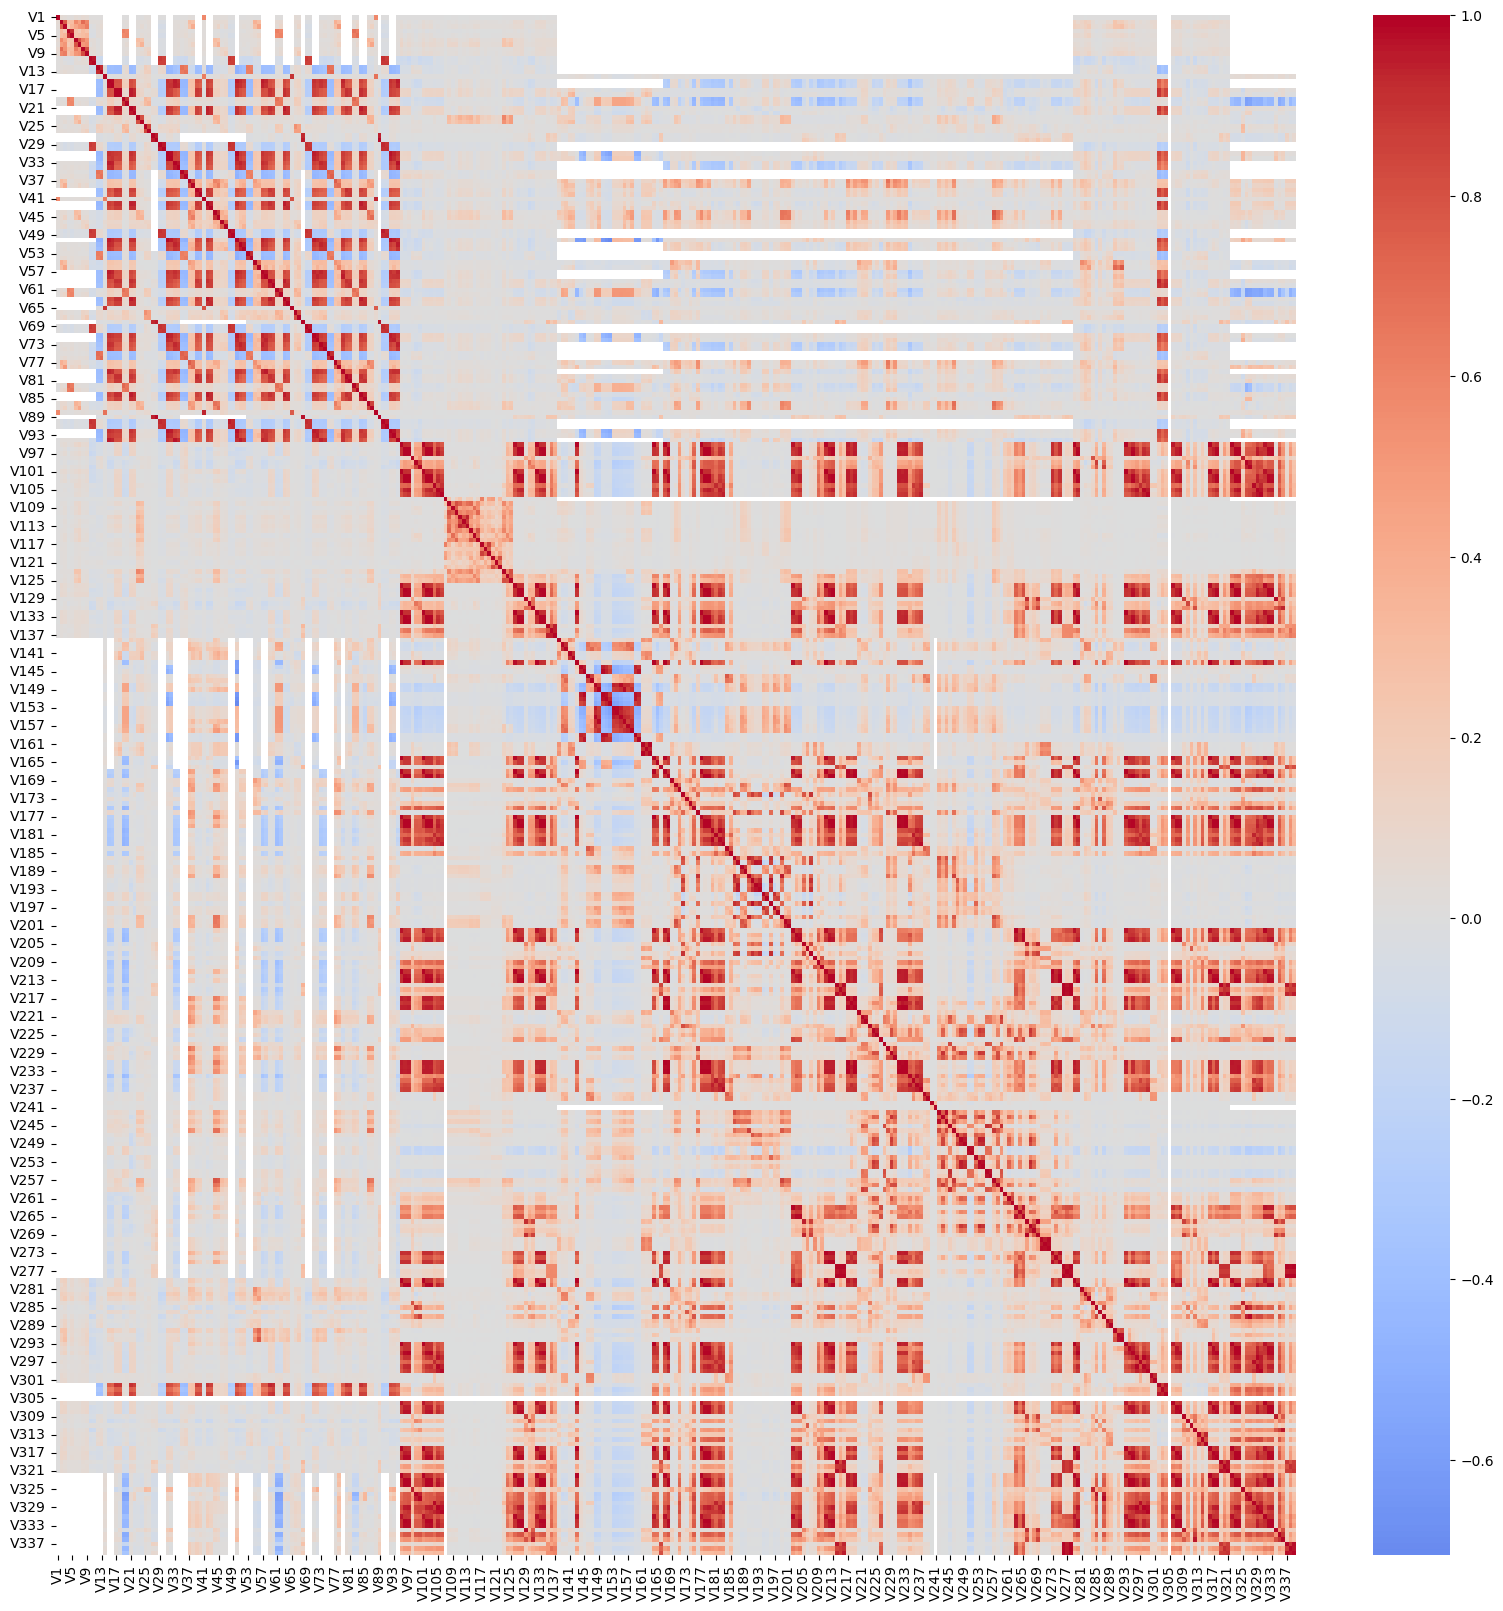

In [24]:
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='coolwarm', center=0)

In [25]:
pd.set_option('display.max_rows', None)

In [26]:
missing = train.isnull().mean() * 100
missing[[f'V{i}' for i in range(1,340)]]

,0
V1,47.293494
V2,47.293494
V3,47.293494
V4,47.293494
V5,47.293494
V6,47.293494
V7,47.293494
V8,47.293494
V9,47.293494
V10,47.293494


In [27]:
# from scipy.cluster.hierarchy import linkage, dendrogram
# sample = train.sample(n=50000, random_state=42)
# corr = sample[[f'V{i}' for i in range(1,340)]].corr()
# Z = linkage(corr, method='ward')
# plt.figure(figsize=(20,8))
# dendrogram(Z)
# plt.show()

###Uper body not run as my RAM crashed and take much times::

In [28]:
def create_v_features(df):
    """Create aggregation features from V columns"""
    print("Creating V-column aggregation features...")

    # Get all V columns
    v_cols = [col for col in df.columns if col.startswith('V')]

    if len(v_cols) == 0:
        return df

    # Group V columns by their correlation patterns and null values
    v_groups = {
        'v1': ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11'],
        'v2': ['V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26'],
        'v3': ['V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34'],
        'v4': ['V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52'],
        'v5': ['V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74'],
        'v6': ['V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94'],
        'v7': ['V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V107', 'V108', 'V109', 'V110', 'V111', 'V112', 'V113', 'V114', 'V115', 'V116', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V123', 'V124', 'V125', 'V126', 'V127', 'V128', 'V129', 'V130', 'V131', 'V132', 'V133', 'V134', 'V135', 'V136', 'V137'],
    }

    for group_name, group_cols in v_groups.items():
        # Filter to existing columns
        existing_cols = [col for col in group_cols if col in df.columns]

        if len(existing_cols) > 0:
            # Sum of group
            df[f'{group_name}_sum'] = df[existing_cols].sum(axis=1)

            # Mean of group
            df[f'{group_name}_mean'] = df[existing_cols].mean(axis=1)

            # Std of group
            df[f'{group_name}_std'] = df[existing_cols].std(axis=1)

            # NaN count in group
            df[f'{group_name}_nan_count'] = df[existing_cols].isna().sum(axis=1)

    # Overall V statistics
    existing_v_cols = [col for col in v_cols if col in df.columns]
    if len(existing_v_cols) > 0:
        df['V_sum_all'] = df[existing_v_cols].sum(axis=1)
        df['V_mean_all'] = df[existing_v_cols].mean(axis=1)
        df['V_std_all'] = df[existing_v_cols].std(axis=1)
        df['V_nan_count_all'] = df[existing_v_cols].isna().sum(axis=1)
        df['V_nan_ratio'] = df['V_nan_count_all'] / len(existing_v_cols)

    return df

# Apply
train = create_v_features(train)
test = create_v_features(test)

Creating V-column aggregation features...
Creating V-column aggregation features...


In [29]:
def create_c_d_features(df):
    """Create features from C (count) and D (timedelta) columns"""
    print("Creating C and D column features...")

    # C columns (counting features)
    c_cols = [col for col in df.columns if col.startswith('C') and col[1:].isdigit()]

    if len(c_cols) > 0:
        existing_c_cols = [col for col in c_cols if col in df.columns]

        # Aggregations
        df['C_sum'] = df[existing_c_cols].sum(axis=1)
        df['C_mean'] = df[existing_c_cols].mean(axis=1)
        df['C_std'] = df[existing_c_cols].std(axis=1)
        df['C_max'] = df[existing_c_cols].max(axis=1)
        df['C_min'] = df[existing_c_cols].min(axis=1)

        # Log transformations for key C columns
        for col in ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']:
            if col in df.columns:
                df[f'{col}_log'] = np.log1p(df[col].fillna(0))

    # D columns (timedelta features)
    d_cols = [col for col in df.columns if col.startswith('D') and col[1:].isdigit()]

    if len(d_cols) > 0:
        existing_d_cols = [col for col in d_cols if col in df.columns]

        # Aggregations
        df['D_sum'] = df[existing_d_cols].sum(axis=1)
        df['D_mean'] = df[existing_d_cols].mean(axis=1)
        df['D_std'] = df[existing_d_cols].std(axis=1)
        df['D_nan_count'] = df[existing_d_cols].isna().sum(axis=1)

        # D1 is often important (days since card was first used)
        if 'D1' in df.columns:
            df['D1_missing'] = df['D1'].isna().astype(int)
            df['D1_log'] = np.log1p(df['D1'].fillna(0))

        # D15 is also important
        if 'D15' in df.columns:
            df['D15_missing'] = df['D15'].isna().astype(int)
            df['D15_log'] = np.log1p(df['D15'].fillna(0))

    return df

# Apply
train = create_c_d_features(train)
test = create_c_d_features(test)

Creating C and D column features...
Creating C and D column features...


In [30]:
train['M1'].value_counts()

,count
M1,
T,319415
F,25


In [31]:
m_cols = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
for i in m_cols:
  print(train[i].value_counts())

M1
T    319415
F        25
Name: count, dtype: int64
M2
T    285468
F     33972
Name: count, dtype: int64
M3
T    251731
F     67709
Name: count, dtype: int64
M4
M0    196405
M2     59865
M1     52826
Name: count, dtype: int64
M5
F    132491
T    107567
Name: count, dtype: int64
M6
F    227856
T    193324
Name: count, dtype: int64
M7
F    211374
T     32901
Name: count, dtype: int64
M8
F    155251
T     89037
Name: count, dtype: int64
M9
T    205656
F     38632
Name: count, dtype: int64


In [32]:
def create_m_features(df):
    """Create features from M (match) columns"""
    print("Creating M column features...")

    m_cols = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
    existing_m_cols = [col for col in m_cols if col in df.columns]

    if len(existing_m_cols) > 0:
        # Count of True values
        for col in existing_m_cols:
            df[f'{col}_isT'] = (df[col] == 'T').astype(int)
            df[f'{col}_isF'] = (df[col] == 'F').astype(int)
            df[f'{col}_missing'] = df[col].isna().astype(int)

        # Total True count
        t_cols = [f'{col}_isT' for col in existing_m_cols]
        df['M_true_count'] = df[t_cols].sum(axis=1)

        # Total False count
        f_cols = [f'{col}_isF' for col in existing_m_cols]
        df['M_false_count'] = df[f_cols].sum(axis=1)

        # Total missing count
        m_missing_cols = [f'{col}_missing' for col in existing_m_cols]
        df['M_missing_count'] = df[m_missing_cols].sum(axis=1)

        # Ratio of True to total non-missing
        df['M_true_ratio'] = df['M_true_count'] / (df['M_true_count'] + df['M_false_count'] + 0.001)

    return df

# Apply
train = create_m_features(train)
test = create_m_features(test)

Creating M column features...
Creating M column features...


In [33]:
def create_id_features(df):
    """Create features from identity columns"""
    print("Creating ID features...")

    # id_01 to id_11 are numerical
    id_num_cols = [f'id_0{i}' for i in range(1, 10)] + ['id_10', 'id_11']
    existing_id_num = [col for col in id_num_cols if col in df.columns]

    if len(existing_id_num) > 0:
        df['id_num_nan_count'] = df[existing_id_num].isna().sum(axis=1)
        df['id_num_mean'] = df[existing_id_num].mean(axis=1)
        df['id_num_std'] = df[existing_id_num].std(axis=1)

    # id_12 to id_38 are categorical
    # Check specific important ones
    if 'id_12' in df.columns:
        df['id_12_isFound'] = (df['id_12'] == 'Found').astype(int)

    if 'id_15' in df.columns:
        df['id_15_isNew'] = (df['id_15'] == 'New').astype(int)
        df['id_15_isFound'] = (df['id_15'] == 'Found').astype(int)

    if 'id_16' in df.columns:
        df['id_16_isFound'] = (df['id_16'] == 'Found').astype(int)

    if 'id_28' in df.columns:
        df['id_28_isNew'] = (df['id_28'] == 'New').astype(int)
        df['id_28_isFound'] = (df['id_28'] == 'Found').astype(int)

    if 'id_29' in df.columns:
        df['id_29_isFound'] = (df['id_29'] == 'Found').astype(int)

    # id_34 (match status)
    if 'id_34' in df.columns:
        df['id_34_match'] = df['id_34'].apply(
            lambda x: int(str(x).split(':')[1]) if pd.notna(x) and ':' in str(x) else -1
        )

    # id_36 features
    if 'id_36' in df.columns:
        df['id_36_isT'] = (df['id_36'] == 'T').astype(int)

    # id_37, id_38 features
    if 'id_37' in df.columns:
        df['id_37_isT'] = (df['id_37'] == 'T').astype(int)

    if 'id_38' in df.columns:
        df['id_38_isT'] = (df['id_38'] == 'T').astype(int)

    return df

# Apply
train = create_id_features(train)
test = create_id_features(test)

Creating ID features...
Creating ID features...


In [34]:
print(f"\nFinal Train Shape: {train.shape}")
print(f"Final Test Shape: {test.shape}")

# Count new features
original_cols = 434  # Approximate original column count after merge
new_features = train.shape[1] - original_cols
print(f"\nNew features created: ~{new_features}")

# Reduce memory
print("\nReducing memory usage...")
train = reduce_mem_usage(train)
test = reduce_mem_usage(test)

gc.collect()


Final Train Shape: (590540, 594)
Final Test Shape: (506691, 579)

New features created: ~160

Reducing memory usage...
Memory usage: 2676.24 MB -> 1304.33 MB (51.3% reduction)
Memory usage: 2238.27 MB -> 1107.05 MB (50.5% reduction)


47

In [35]:
# Separate target and features
y_train = train['isFraud']
X_train = train.drop(['isFraud', 'TransactionID', 'TransactionDT'], axis=1, errors='ignore')
X_test = test.drop(['TransactionID', 'TransactionDT'], axis=1, errors='ignore')

# Store TransactionID for submission
test_id = test['TransactionID']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Align columns between train and test
common_cols = [col for col in X_train.columns if col in X_test.columns]
print(f"Common columns: {len(common_cols)}")

train_only_cols = [col for col in X_train.columns if col not in X_test.columns]
test_only_cols = [col for col in X_test.columns if col not in X_train.columns]

if train_only_cols:
    print(f"Columns only in train (dropping): {len(train_only_cols)}")
if test_only_cols:
    print(f"Columns only in test (dropping): {len(test_only_cols)}")

X_train = X_train[common_cols]
X_test = X_test[common_cols]

print(f"\nAfter alignment:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int8', 'int16', 'int32', 'int64', 'float32', 'float64']).columns.tolist()

print(f"Categorical columns: {len(categorical_cols)}")
print(f"Numerical columns: {len(numerical_cols)}")

# Label encode categorical features
print("Encoding categorical features...")
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([X_train[col].astype(str), X_test[col].astype(str)], axis=0)
    le.fit(combined)

    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

print("Encoding completed!")

# Handle missing values
print("Filling missing values...")
X_train = X_train.fillna(-999)
X_test = X_test.fillna(-999)

# Free memory
del train, test
gc.collect()

X_train shape: (590540, 591)
X_test shape: (506691, 577)
Common columns: 539
Columns only in train (dropping): 52
Columns only in test (dropping): 38

After alignment:
X_train shape: (590540, 539)
X_test shape: (506691, 539)
Categorical columns: 32
Numerical columns: 507
Encoding categorical features...
Encoding completed!
Filling missing values...


0

## 19. Model Training with LightGBM

In [36]:
# Split data for validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# LightGBM parameters (tuned for fraud detection)
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 256,
    'max_depth': -1,
    'min_child_samples': 50,
    'max_bin': 255,
    'subsample': 0.8,
    'subsample_freq': 1,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.5,
    'reg_lambda': 0.5,
    'min_split_gain': 0.01,
    'n_jobs': -1,
    'random_state': 42,
    'verbosity': -1,
    'is_unbalance': True  # Handle class imbalance
}

# Create LightGBM datasets
train_data = lgb.Dataset(X_tr, label=y_tr)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# Train model
print("Training LightGBM model...")
model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=1500,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best validation AUC: {model.best_score['valid']['auc']:.6f}")

Training LightGBM model...
Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.981915	valid's auc: 0.948178
[200]	train's auc: 0.993014	valid's auc: 0.960335
[300]	train's auc: 0.99706	valid's auc: 0.965183
[400]	train's auc: 0.99865	valid's auc: 0.967741
[500]	train's auc: 0.999347	valid's auc: 0.96928
[600]	train's auc: 0.99966	valid's auc: 0.970542
[700]	train's auc: 0.999824	valid's auc: 0.971134
[800]	train's auc: 0.999911	valid's auc: 0.971666
[900]	train's auc: 0.999957	valid's auc: 0.972058
[1000]	train's auc: 0.99998	valid's auc: 0.972638
[1100]	train's auc: 0.99999	valid's auc: 0.972982
[1200]	train's auc: 0.999996	valid's auc: 0.973334
Early stopping, best iteration is:
[1191]	train's auc: 0.999995	valid's auc: 0.973343

Best iteration: 1191
Best validation AUC: 0.973343


Validation ROC-AUC: 0.973343


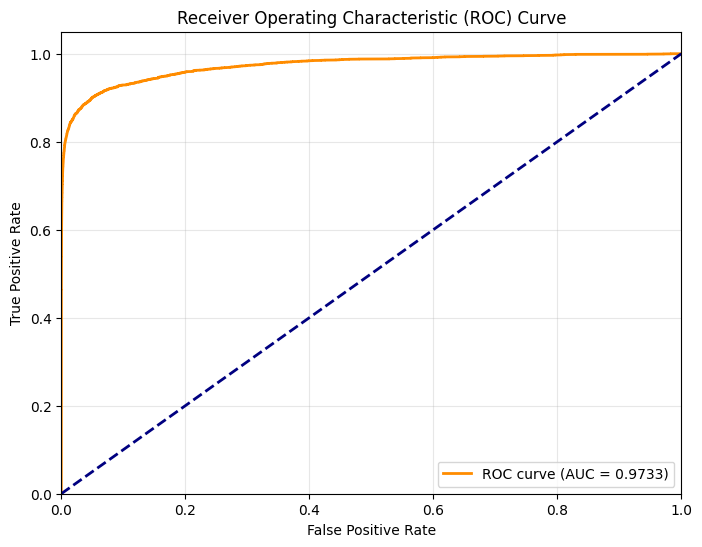

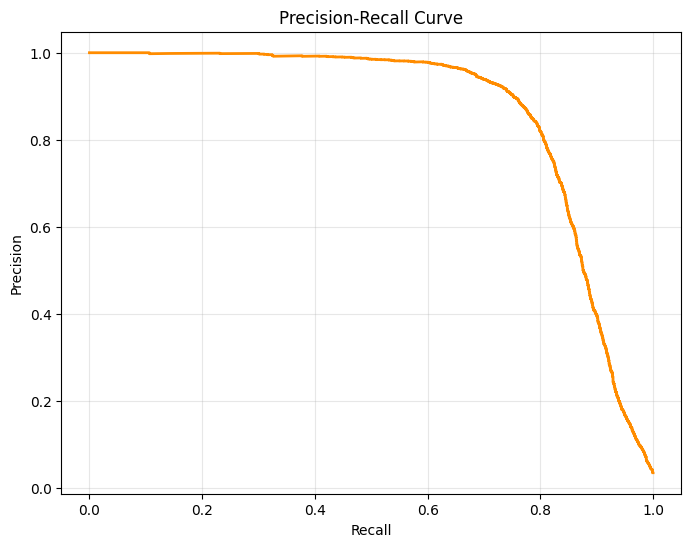

Optimal Threshold: 0.5928
Precision at optimal: 0.8943
Recall at optimal: 0.7597
F1 at optimal: 0.8216


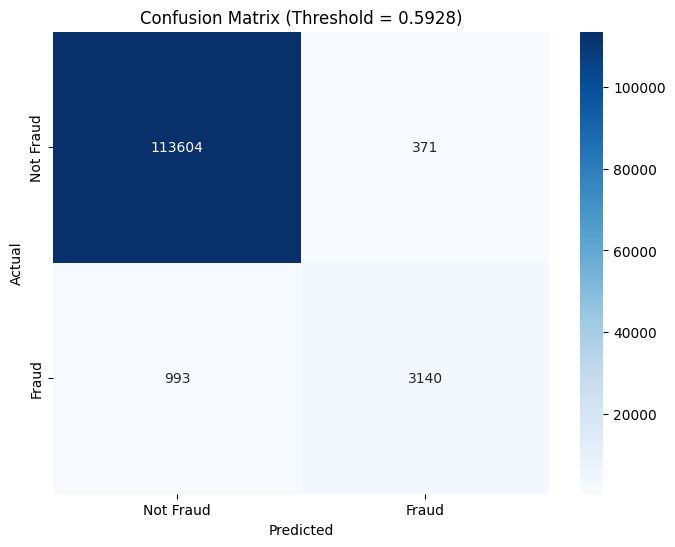


Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.99      1.00      0.99    113975
       Fraud       0.89      0.76      0.82      4133

    accuracy                           0.99    118108
   macro avg       0.94      0.88      0.91    118108
weighted avg       0.99      0.99      0.99    118108



In [37]:
# Predictions on validation set
y_val_pred = model.predict(X_val, num_iteration=model.best_iteration)

# Calculate AUC
val_auc = roc_auc_score(y_val, y_val_pred)
print(f"Validation ROC-AUC: {val_auc:.6f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(y_val, y_val_pred)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True, alpha=0.3)
plt.show()

# Find optimal threshold
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = pr_thresholds[optimal_idx] if optimal_idx < len(pr_thresholds) else 0.5

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Precision at optimal: {precision[optimal_idx]:.4f}")
print(f"Recall at optimal: {recall[optimal_idx]:.4f}")
print(f"F1 at optimal: {f1_scores[optimal_idx]:.4f}")

# Confusion Matrix
y_val_binary = (y_val_pred >= optimal_threshold).astype(int)

cm = confusion_matrix(y_val, y_val_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title(f'Confusion Matrix (Threshold = {optimal_threshold:.4f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_val, y_val_binary, target_names=['Not Fraud', 'Fraud']))

Top 50 Most Important Features:
                   feature     importance
0                     V258  977675.458142
1                      V70  513645.019151
2                      C14  477887.934350
3           TransactionAmt  458990.481924
4                    card1  440400.715521
5              card2_addr1  371034.447930
6         Transaction_week  358017.272051
7                     V317  345924.086385
8                    card2  289321.425458
9          Transaction_dom  264322.103504
10                   addr1  258429.528973
11                     V91  247248.158570
12              V_mean_all  243845.057559
13                     C13  229941.156158
14             card1_card2  222788.956213
15             card1_addr1  197057.407784
16                      C8  192060.306998
17                   D_sum  190370.661696
18        Transaction_hour  186774.437353
19                   D_std  186747.173543
20                   card5  186537.865797
21             addr1_addr2  178502.462672
22

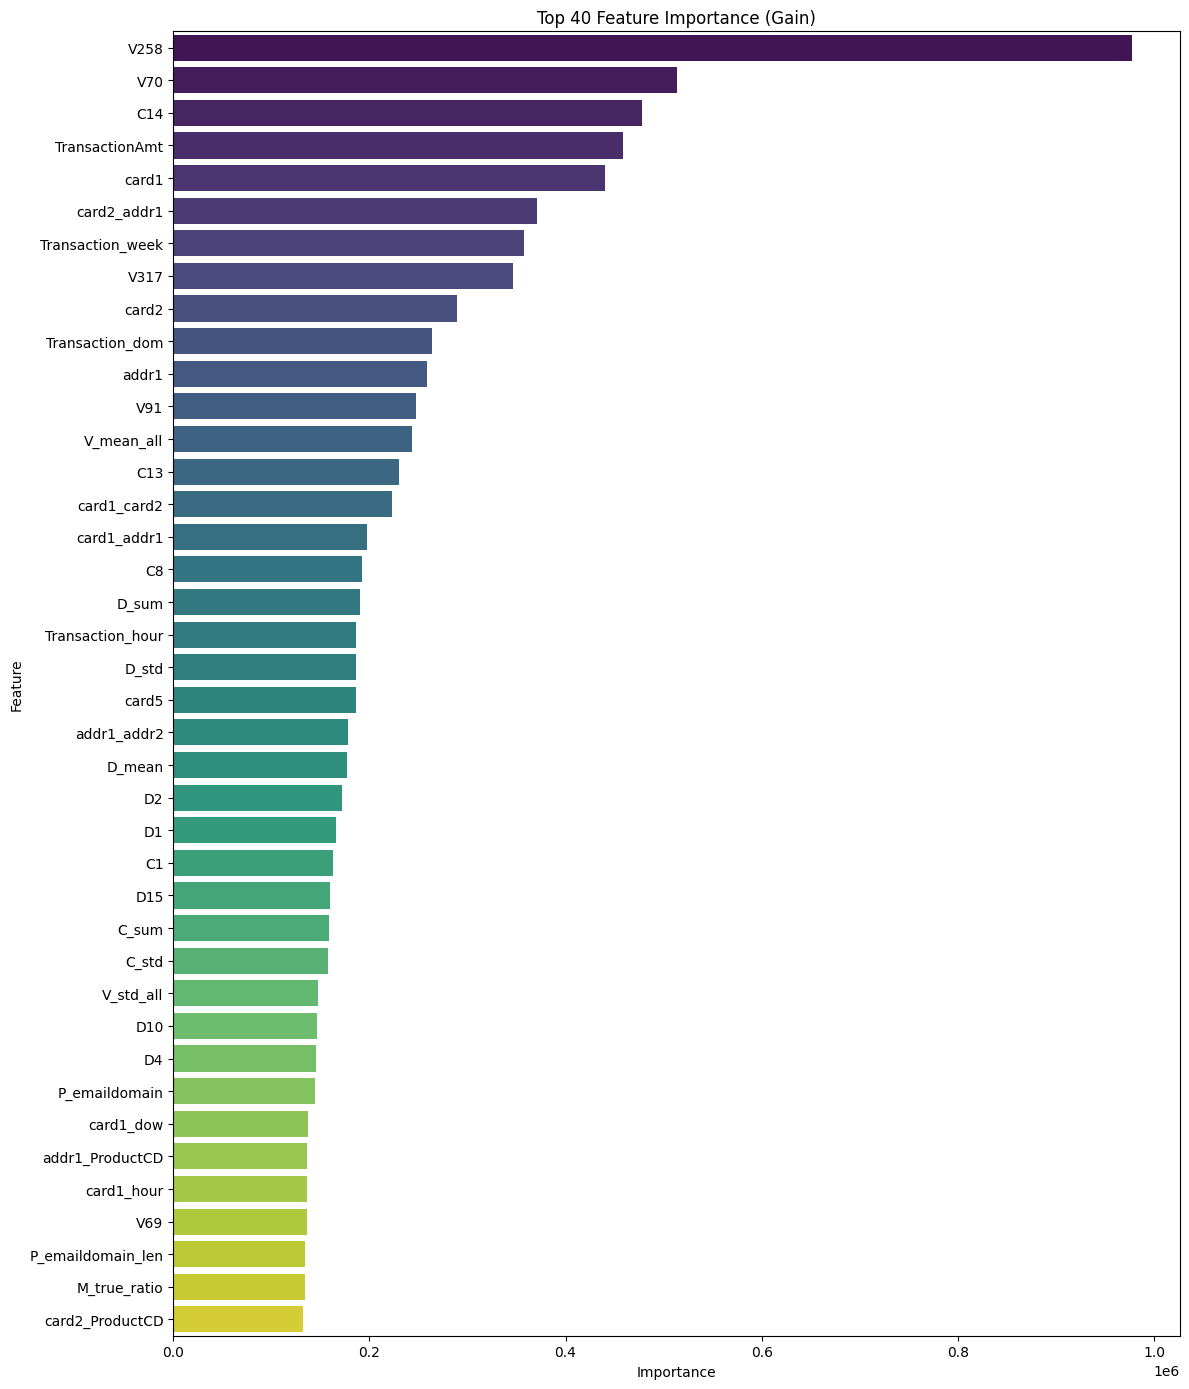


Engineered features in top 50: 21

Top 20 Engineered Features:
                   feature     importance
5              card2_addr1  371034.447930
6         Transaction_week  358017.272051
9          Transaction_dom  264322.103504
12              V_mean_all  243845.057559
14             card1_card2  222788.956213
15             card1_addr1  197057.407784
17                   D_sum  190370.661696
18        Transaction_hour  186774.437353
19                   D_std  186747.173543
22                  D_mean  177198.825254
27                   C_sum  159038.911236
28                   C_std  158109.805670
29               V_std_all  148039.246720
32           P_emaildomain  144280.978830
33               card1_dow  137131.339222
35              card1_hour  136668.218127
37       P_emaildomain_len  134538.497431
39         card2_ProductCD  132376.282552
40  TransactionAmt_decimal  131927.358009
41      TransactionAmt_Log  130406.013395


In [38]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 50 Most Important Features:")
print(feature_importance.head(50))

# Visualize top 40 features
plt.figure(figsize=(12, 14))
sns.barplot(data=feature_importance.head(40), x='importance', y='feature', palette='viridis')
plt.title('Top 40 Feature Importance (Gain)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Analyze engineered features importance
engineered_keywords = ['_Log', '_decimal', '_freq', '_mean', '_std', '_count', '_sum',
                       '_is_', '_nan', '_missing', '_match', '_dev', 'Transaction_',
                       'card1_', 'card2_', 'Browser', 'OS', 'Screen', 'email']

engineered_features = feature_importance[
    feature_importance['feature'].apply(
        lambda x: any(kw in x for kw in engineered_keywords)
    )
]

print(f"\nEngineered features in top 50: {len(engineered_features[engineered_features.index < 50])}")
print("\nTop 20 Engineered Features:")
print(engineered_features.head(20))

Running 4-Fold Cross Validation...

Fold 1/4
Training until validation scores don't improve for 80 rounds
[200]	valid's auc: 0.958435
[400]	valid's auc: 0.965046
[600]	valid's auc: 0.967047
Did not meet early stopping. Best iteration is:
[599]	valid's auc: 0.967058
Fold AUC : 0.967058

Fold 2/4
Training until validation scores don't improve for 80 rounds
[200]	valid's auc: 0.958816
[400]	valid's auc: 0.965413
[600]	valid's auc: 0.967664
Did not meet early stopping. Best iteration is:
[599]	valid's auc: 0.967675
Fold AUC : 0.967675

Fold 3/4
Training until validation scores don't improve for 80 rounds
[200]	valid's auc: 0.958311
[400]	valid's auc: 0.965238
[600]	valid's auc: 0.967505
Did not meet early stopping. Best iteration is:
[593]	valid's auc: 0.967562
Fold AUC : 0.967562

Fold 4/4
Training until validation scores don't improve for 80 rounds
[200]	valid's auc: 0.960853
[400]	valid's auc: 0.967813
[600]	valid's auc: 0.970641
Did not meet early stopping. Best iteration is:
[600]	val

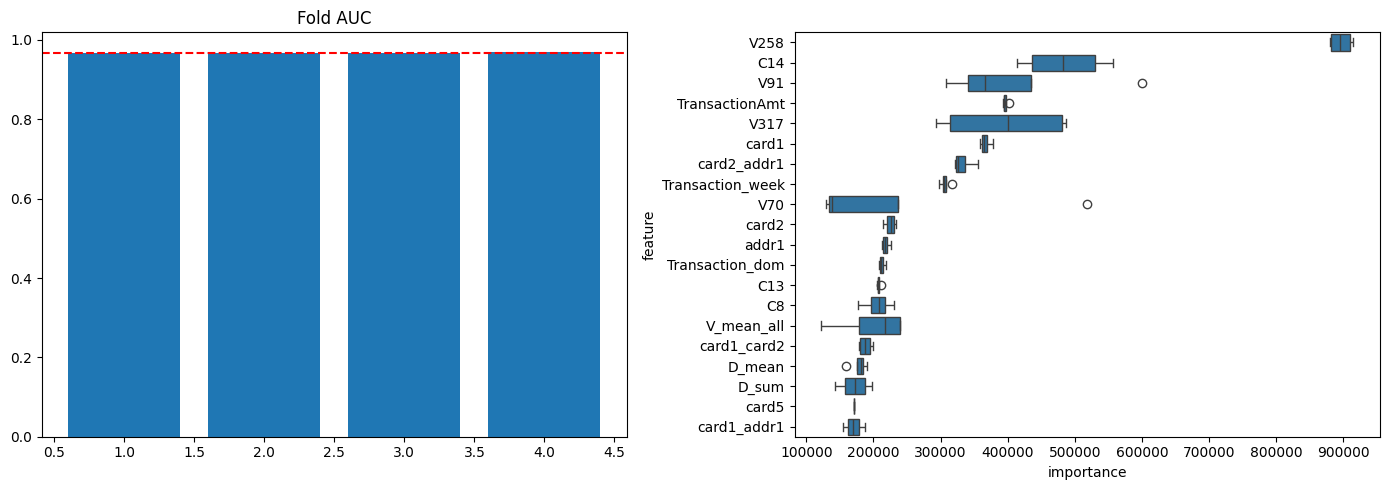

In [39]:
print("Running 4-Fold Cross Validation...")

n_folds = 4
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(X_train), dtype=np.float32)
test_predictions = np.zeros(len(X_test), dtype=np.float32)

cv_scores = []
feature_importance_list = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):

    print(f"\n{'='*50}")
    print(f"Fold {fold+1}/{n_folds}")
    print(f"{'='*50}")

    X_tr_fold = X_train.iloc[train_idx]
    y_tr_fold = y_train.iloc[train_idx]

    X_val_fold = X_train.iloc[val_idx]
    y_val_fold = y_train.iloc[val_idx]

    train_data = lgb.Dataset(X_tr_fold, label=y_tr_fold)
    valid_data = lgb.Dataset(X_val_fold, label=y_val_fold)

    model = lgb.train(
        lgb_params,
        train_data,
        num_boost_round=600,
        valid_sets=[valid_data],
        valid_names=['valid'],
        callbacks=[
            lgb.early_stopping(80),
            lgb.log_evaluation(200)
        ]
    )

    pred_val = model.predict(
        X_val_fold,
        num_iteration=model.best_iteration
    )

    pred_test = model.predict(
        X_test,
        num_iteration=model.best_iteration
    )

    oof_predictions[val_idx] = pred_val
    test_predictions += pred_test / n_folds

    fold_score = roc_auc_score(y_val_fold, pred_val)
    cv_scores.append(fold_score)

    print(f"Fold AUC : {fold_score:.6f}")

    feature_importance_list.append(
        pd.DataFrame({
            "feature": X_train.columns,
            "importance": model.feature_importance(
                importance_type="gain"
            ),
            "fold": fold+1
        })
    )

    # -------- FREE MEMORY --------
    del X_tr_fold
    del X_val_fold
    del y_tr_fold
    del y_val_fold
    del train_data
    del valid_data
    del pred_val
    del pred_test
    del model

    gc.collect()

feature_importances = pd.concat(
    feature_importance_list,
    ignore_index=True
)

oof_auc = roc_auc_score(y_train, oof_predictions)

print("\n===============================")
print(f"Mean CV AUC : {np.mean(cv_scores):.6f}")
print(f"Std CV AUC  : {np.std(cv_scores):.6f}")
print(f"OOF AUC     : {oof_auc:.6f}")

fig, axes = plt.subplots(1,2,figsize=(14,5))

axes[0].bar(
    range(1,n_folds+1),
    cv_scores
)

axes[0].axhline(
    np.mean(cv_scores),
    color='red',
    linestyle='--'
)

axes[0].set_title("Fold AUC")

top_features = (
    feature_importances
    .groupby("feature")["importance"]
    .mean()
    .nlargest(20)
    .index
)

top_fi = feature_importances[
    feature_importances.feature.isin(top_features)
]

sns.boxplot(
    data=top_fi,
    x="importance",
    y="feature",
    order=top_features,
    ax=axes[1]
)

plt.tight_layout()
plt.show()